# 02 - Returns and Risk

Calculate daily and cumulative returns for each asset, and compute basic risk statistics (volatility) as a foundation for later performance evaluation.


## Setup

Load the price data cached by `01_market_data.ipynb` rather than re-downloading it.


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd().parent / "src"))
import data
import performance

prices = data.load_prices()
prices.head()


,Date,Ticker,Open,High,Low,Close,Volume
0,2010-01-04,AAPL,6.383613,6.415617,6.352208,6.400961,493729600
1,2010-01-05,AAPL,6.418607,6.448217,6.378228,6.412026,601904800
2,2010-01-06,AAPL,6.412026,6.437449,6.303454,6.310034,552160000
3,2010-01-07,AAPL,6.333363,6.340841,6.252607,6.298368,477131200
4,2010-01-08,AAPL,6.289996,6.340843,6.252909,6.340244,447610800


## Daily returns

We use **simple daily returns** (`(P_t / P_t-1) - 1`) rather than log returns. Simple returns are what actually compounds an account balance day to day, and they aggregate correctly across multiple assets in a portfolio (log returns don't -- the log return of a portfolio isn't the weighted sum of its components' log returns, but simple returns are). Log returns are convenient for other things (they're time-additive), but we don't need that property here.

Note the first row per ticker has `NaN` -- there's no prior day to compute a return against.


In [2]:
returns = performance.daily_returns(prices)
returns[["Date", "Ticker", "Close", "Return"]].head()


,Date,Ticker,Close,Return
0,2010-01-04,AAPL,6.400961,NaN
1,2010-01-05,AAPL,6.412026,0.001729
2,2010-01-06,AAPL,6.310034,-0.015906
3,2010-01-07,AAPL,6.298368,-0.001849
4,2010-01-08,AAPL,6.340244,0.006649


## Cumulative returns

Growth of $1 invested at the start of the sample, per ticker: `CumReturn = (1 + Return).cumprod() - 1`.


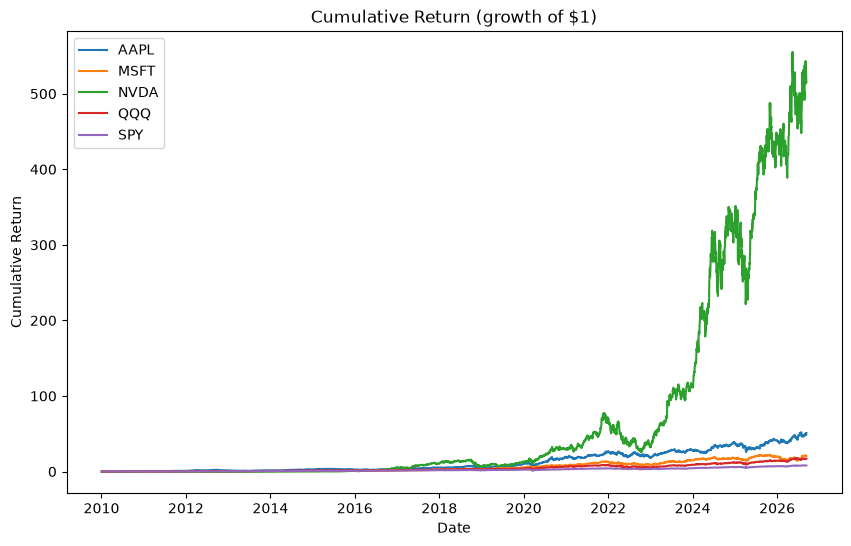

In [3]:
cum = performance.cumulative_returns(returns)

fig, ax = plt.subplots(figsize=(10, 6))
for ticker, group in cum.groupby("Ticker"):
    ax.plot(group["Date"], group["CumReturn"], label=ticker)

ax.set_title("Cumulative Return (growth of $1)")
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative Return")
ax.legend()
plt.show()


## Basic risk statistics

We annualize daily volatility by scaling with `sqrt(252)` (the approximate number of US trading days per year), assuming returns are roughly independent day to day. `annualized_return` here is a simple scaling of the mean daily return -- it's **not** CAGR (compound annual growth rate); we'll compute proper CAGR once we have full backtest equity curves in a later notebook.


In [4]:
performance.summary_stats(returns)


,mean_daily_return,daily_volatility,annualized_return,annualized_volatility
Ticker,,,,
AAPL,0.001098,0.017722,0.276803,0.281326
MSFT,0.000867,0.016422,0.218365,0.260688
NVDA,0.001896,0.028625,0.477684,0.454411
QQQ,0.000770,0.013009,0.194166,0.206517
SPY,0.000583,0.010750,0.146801,0.170655


## Volatility over time

Volatility isn't constant -- it clusters (calm periods and turbulent periods tend to persist). A rolling 21-trading-day (~1 month) annualized volatility makes this visible, and previews why a fixed-position strategy behaves very differently in calm vs. turbulent regimes.


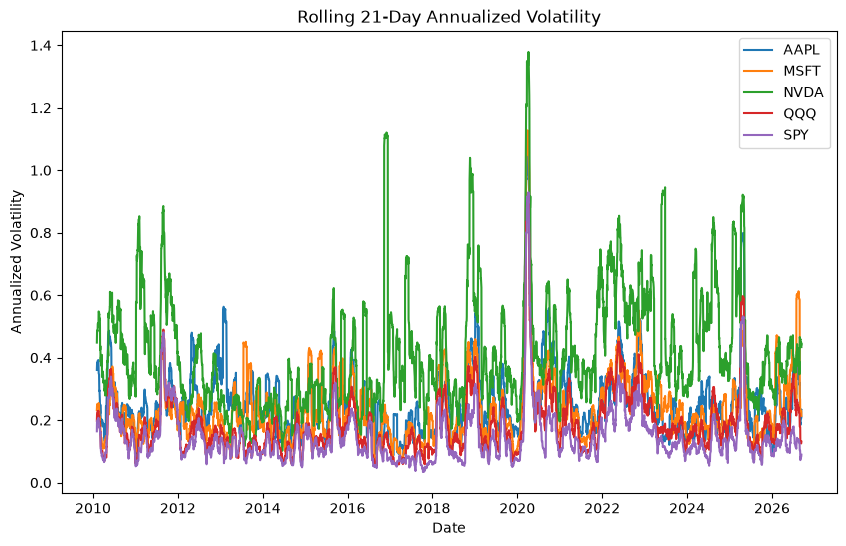

In [5]:
rolling = performance.rolling_annualized_volatility(returns)

fig, ax = plt.subplots(figsize=(10, 6))
for ticker, group in rolling.groupby("Ticker"):
    ax.plot(group["Date"], group["RollingVol"], label=ticker)

ax.set_title("Rolling 21-Day Annualized Volatility")
ax.set_xlabel("Date")
ax.set_ylabel("Annualized Volatility")
ax.legend()
plt.show()


## Notes / Next Step

NVDA shows both the highest average return and by far the highest volatility of the five tickers; SPY (broad index) is the most muted on both counts, as expected for a diversified index vs. individual stocks. Volatility clearly spikes around known market-stress periods rather than staying constant.

**Next:** `03_strategy_signals.ipynb` -- build the 50-day / 200-day moving-average crossover signal that decides when the strategy is long vs. in cash.
